In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

RANDOM_STATE = 42

## 1) ΔΕΔΟΜΕΝΑ ΚΑΙ ΠΡΟΕΤΟΙΜΑΣΙΑ
### ΦΟΡΤΩΣΗ ΚΑΙ ΒΑΣΙΚΑ ΣΤΟΙΧΕΙΑ ΔΕΔΟΜΕΝΩΝ

In [2]:
#Διαβάζει τα δεδομένα 
df = pd.read_csv("data_Fraud.csv")

In [3]:
df.head()

,fyear,gvkey,p_aaer,misstate,act,ap,at,ceq,che,cogs,...,soft_assets,ch_cs,ch_cm,ch_roa,issue,bm,dpi,reoa,EBIT,ch_fcf
0,1990,1009,NaN,0,10.047,3.736,32.335,6.262,0.002,30.633,...,0.312448,0.095082,0.082631,-0.019761,1,0.413170,0.873555,0.167620,0.161961,-0.042140
1,1990,1011,NaN,0,1.247,0.803,7.784,0.667,0.171,1.125,...,0.315904,0.188832,-0.211389,-0.117832,1,0.157887,0.745139,-0.428957,-0.157888,0.100228
2,1990,1017,NaN,0,55.040,3.601,118.120,44.393,3.132,107.343,...,0.605342,0.097551,-0.105780,0.091206,1,2.231337,1.015131,0.394768,0.063681,0.066348
3,1990,1021,NaN,0,24.684,3.948,34.591,7.751,0.411,31.214,...,0.793068,-0.005725,-0.249704,0.017545,1,1.043582,1.026261,0.094822,0.088347,-0.017358
4,1990,1028,NaN,0,17.325,3.520,27.542,-12.142,1.017,32.662,...,0.869182,-0.231536,-1.674893,-0.466667,0,-1.602508,0.598443,-0.942379,-0.700821,0.130349


In [4]:
#Τα δεδομένα έχουν 146045 γραμμές και 46 στήλες
print(df.shape) 

(146045, 46)


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 146045 entries, 0 to 146044
Data columns (total 46 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   fyear        146045 non-null  int64  
 1   gvkey        146045 non-null  int64  
 2   p_aaer       964 non-null     float64
 3   misstate     146045 non-null  int64  
 4   act          146045 non-null  float64
 5   ap           146045 non-null  float64
 6   at           146045 non-null  float64
 7   ceq          146045 non-null  float64
 8   che          146045 non-null  float64
 9   cogs         146045 non-null  float64
 10  csho         146045 non-null  float64
 11  dlc          146045 non-null  float64
 12  dltis        146045 non-null  float64
 13  dltt         146045 non-null  float64
 14  dp           146045 non-null  float64
 15  ib           146045 non-null  float64
 16  invt         146045 non-null  float64
 17  ivao         146045 non-null  float64
 18  ivst         146045 non-null  float

In [6]:
#Οι στήλες του dataset είναι οι εξής:
df.columns

Index(['fyear', 'gvkey', 'p_aaer', 'misstate', 'act', 'ap', 'at', 'ceq', 'che',
       'cogs', 'csho', 'dlc', 'dltis', 'dltt', 'dp', 'ib', 'invt', 'ivao',
       'ivst', 'lct', 'lt', 'ni', 'ppegt', 'pstk', 're', 'rect', 'sale',
       'sstk', 'txp', 'txt', 'xint', 'prcc_f', 'dch_wc', 'ch_rsst', 'dch_rec',
       'dch_inv', 'soft_assets', 'ch_cs', 'ch_cm', 'ch_roa', 'issue', 'bm',
       'dpi', 'reoa', 'EBIT', 'ch_fcf'],
      dtype='str')

In [7]:
#Το εύρος των ετών είναι από το 1990 εως το 2014
print(df['fyear'].min(), "-", df['fyear'].max())

1990 - 2014


In [21]:
#Περιγραφικά στατιστιά στοιχεία για το dataset
df.describe() 

,fyear,gvkey,p_aaer,misstate,act,ap,at,ceq,che,cogs,...,soft_assets,ch_cs,ch_cm,ch_roa,issue,bm,dpi,reoa,EBIT,ch_fcf
count,146045.000000,146045.000000,964.000000,146045.000000,146045.000000,146045.000000,146045.000000,146045.000000,146045.000000,146045.000000,...,145453.000000,130127.000000,128938.000000,133367.000000,146045.000000,146027.000000,136817.000000,145454.000000,145454.000000,140638.000000
mean,2002.011702,54243.435516,2503.840249,0.006601,737.847759,181.993488,2374.041576,887.126243,218.657186,1302.280756,...,0.499790,0.185169,-0.090980,-0.010208,0.863487,0.466137,1.042207,-3.191197,-0.238754,-0.008842
std,6.959894,59937.455765,912.093250,0.080976,3744.542368,1047.546104,11957.736980,5056.948150,1330.490185,7870.665783,...,0.274129,1.383354,2.844807,0.379574,0.343333,1.314661,0.495286,12.932219,1.059134,0.548216
min,1990.000000,1004.000000,371.000000,0.000000,-0.254000,0.000000,0.000000,-25560.000000,-34.000000,-366.645000,...,0.004515,-6.484197,-17.359699,-1.671565,0.000000,-7.034304,0.151757,-89.013245,-7.016393,-2.980601
25%,1996.000000,10658.000000,1803.000000,0.000000,8.277000,1.151000,18.281000,6.337000,1.144000,6.795000,...,0.270023,-0.073635,-0.260164,-0.058635,1.000000,0.191546,0.854248,-0.894633,-0.128135,-0.123402
50%,2002.000000,25088.000000,2620.500000,0.000000,47.501000,6.462000,105.346000,47.308000,9.373000,53.382000,...,0.524640,0.067918,-0.023205,-0.001893,1.000000,0.442172,0.974302,-0.008046,0.043701,-0.026155
75%,2008.000000,66586.000000,3180.000000,0.000000,249.832000,42.259000,672.929000,271.547000,60.286000,372.730000,...,0.726663,0.250237,0.139960,0.042188,1.000000,0.805320,1.097582,0.229724,0.108059,0.062294
max,2014.000000,317264.000000,3996.000000,1.000000,152629.000000,39903.000000,410074.000000,284434.000000,85709.000000,435726.253000,...,0.993599,9.600000,16.573810,1.621628,1.000000,4.937457,4.036458,0.784573,0.550619,4.061810


In [8]:
#Το ποσοστό της κάθε κλάσης στην στήλη misstate (0 = No Fraud, 1 = Fraud)
print(df['misstate'].value_counts())
print(df['misstate'].value_counts(normalize=True) * 100) #εμφανιση σε ποσοστο

misstate
0    145081
1       964
Name: count, dtype: int64
misstate
0    99.339929
1     0.660071
Name: proportion, dtype: float64


In [9]:
#Ποιές στήλες τα περισσότερα missing values
print(df.isnull().sum().sort_values(ascending=False).head(10))

p_aaer     145081
ch_cm       17107
ch_cs       15918
ch_roa      12678
dpi          9228
ch_fcf       5407
ch_rsst      4851
dch_wc       4759
dch_rec      4743
dch_inv      4615
dtype: int64


### ΣΥΝΤΟΜΗ ΟΠΤΙΚΟΠΟΙΗΣΗ ΤΟΥ ΣΥΝΟΛΟΥ ΔΕΔΟΜΕΝΩΝ

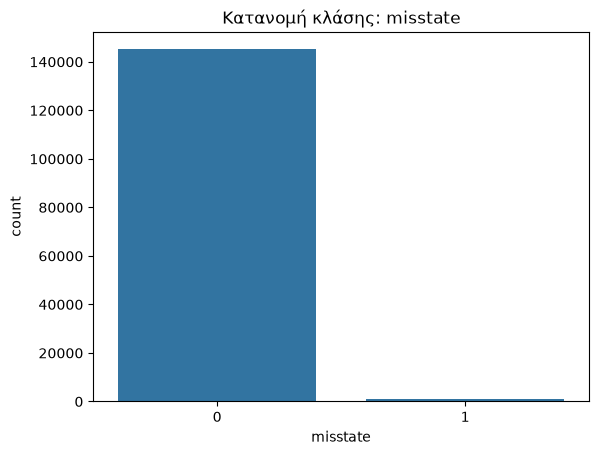

In [22]:
#Κατανομή κλάσης misstate
sns.countplot(x='misstate', data=df)
plt.title('Κατανομή κλάσης: misstate')
plt.show()

In [28]:
#Ποσοστό απάτης ανά χρονιά 
print(df.groupby('fyear')['misstate'].mean() * 100)

fyear
1990    0.327368
1991    0.572884
1992    0.523139
1993    0.557932
1994    0.404645
1995    0.353130
1996    0.489251
1997    0.618648
1998    0.833830
1999    1.069127
2000    1.273697
2001    1.273185
2002    1.269161
2003    1.153653
2004    0.977418
2005    0.767525
2006    0.558565
2007    0.511247
2008    0.463293
2009    0.577604
2010    0.482464
2011    0.388601
2012    0.337478
2013    0.194794
2014    0.071086
Name: misstate, dtype: float64


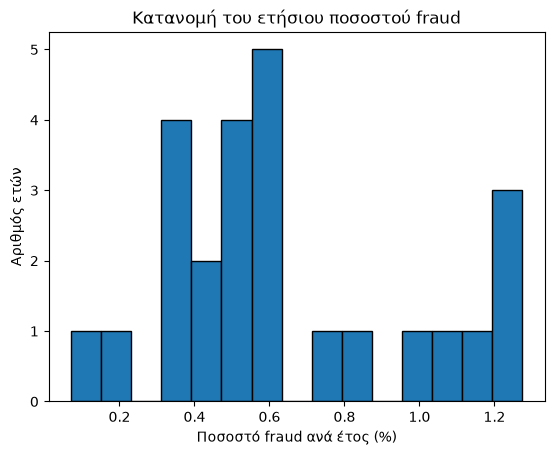

In [40]:
fraud_rate_by_year = df.groupby('fyear')['misstate'].mean() * 100

plt.hist(fraud_rate_by_year, bins=15, edgecolor='black')
plt.xlabel('Ποσοστό fraud ανά έτος (%)')
plt.ylabel('Αριθμός ετών')
plt.title('Κατανομή του ετήσιου ποσοστού fraud')
plt.show()

### Το παραπάνω διάγραμμα μας δείχνει το πλήθος των ετών που αντιστοιχεί σε κάθε fraud rate.

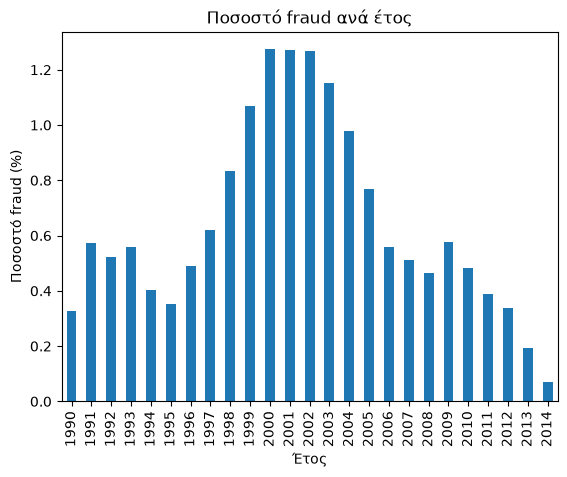

In [35]:
fraud_rate_by_year.plot(kind='bar')
plt.xlabel('Έτος')
plt.ylabel('Ποσοστό fraud (%)')
plt.title('Ποσοστό fraud ανά έτος')
plt.show()

### Το παραπάνω διάγραμμα απεικονίζει για κάθε έτος ποιό είναι το ποσοστό απάτης.

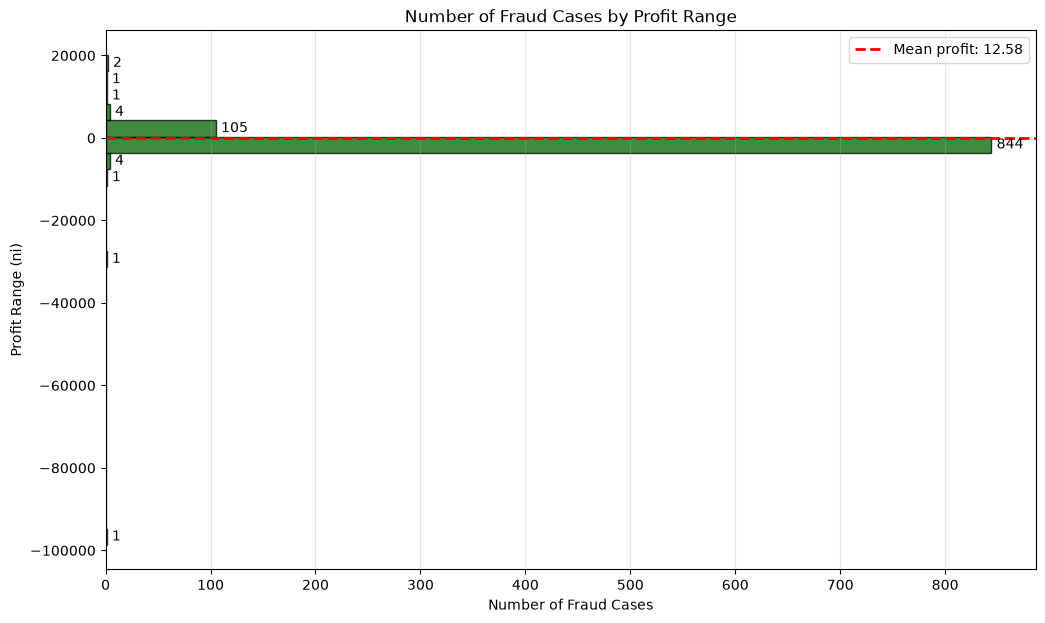

In [54]:
fraud_profits = df.loc[df['misstate'] == 1, 'ni'].dropna()
average_profit = fraud_profits.mean()

counts, profit_bins = np.histogram(fraud_profits, bins=30)
bin_centers = (profit_bins[:-1] + profit_bins[1:]) / 2
bin_heights = np.diff(profit_bins)

plt.figure(figsize=(12, 7))
plt.barh(
    bin_centers,
    counts,
    height=bin_heights,
    color='darkgreen',
    edgecolor='black',
    alpha=0.75
 )
plt.axhline(
    average_profit,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Mean profit: {average_profit:,.2f}'
 )
for count, bin_center in zip(counts, bin_centers):
    if count > 0:
        plt.text(count + 5, bin_center, str(count), va='center')

plt.title('Number of Fraud Cases by Profit Range')
plt.xlabel('Number of Fraud Cases')
plt.ylabel('Profit Range (ni)')
plt.ticklabel_format(style='plain', axis='y')
plt.legend()
plt.grid(axis='x', alpha=0.3)
plt.show()

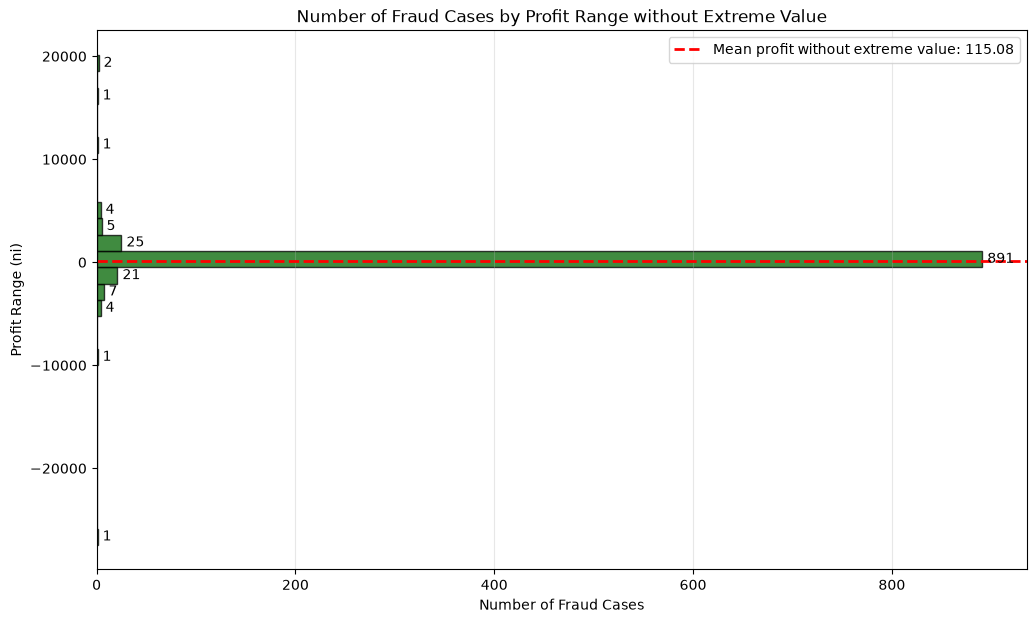

In [55]:
fraud_profits_without_extreme = fraud_profits[fraud_profits != fraud_profits.min()]
average_profit_without_extreme = fraud_profits_without_extreme.mean()

counts, profit_bins = np.histogram(fraud_profits_without_extreme, bins=30)
bin_centers = (profit_bins[:-1] + profit_bins[1:]) / 2
bin_heights = np.diff(profit_bins)

plt.figure(figsize=(12, 7))
plt.barh(
    bin_centers,
    counts,
    height=bin_heights,
    color='darkgreen',
    edgecolor='black',
    alpha=0.75
 )
plt.axhline(
    average_profit_without_extreme,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Mean profit without extreme value: {average_profit_without_extreme:,.2f}'
 )
for count, bin_center in zip(counts, bin_centers):
    if count > 0:
        plt.text(count + 5, bin_center, str(count), va='center')

plt.title('Number of Fraud Cases by Profit Range without Extreme Value')
plt.xlabel('Number of Fraud Cases')
plt.ylabel('Profit Range (ni)')
plt.ticklabel_format(style='plain', axis='y')
plt.legend()
plt.grid(axis='x', alpha=0.3)
plt.show()

In [20]:
# Στήλες "change" που εντοπίσαμε ότι έχουν missing values
change_cols = ['ch_cm', 'ch_cs', 'ch_roa', 'dpi', 'ch_fcf', 
               'ch_rsst', 'dch_wc', 'dch_rec', 'dch_inv']

# Πόσες γραμμές έχουν τουλάχιστον ένα missing σε αυτές τις στήλες
mask_any_missing = df[change_cols].isnull().any(axis=1)
print(f"Γραμμές με missing σε change-μεταβλητές: {mask_any_missing.sum()} "
      f"({mask_any_missing.mean()*100:.2f}%)\n")

# Εμφνανιση ποσοστού misstate=1 για τς γραμμές που έχουν missing value
print("Ποσοστό misstate=1 ανάλογα με missing status")
print(df.groupby(mask_any_missing)['misstate'].mean() * 100) # ο μέσος όρος ειναι ο αριθμός των fraud αφου το misstate ειναι 0 ή 1.
print()

# Πόσες γραμμές θα μείνουν αν κάνουμε drop
remaining = df[~mask_any_missing]
print(f"Γραμμές μετά το drop: {remaining.shape[0]}")
print(f"Fraud rate μετά το drop: {remaining['misstate'].mean()*100:.3f}%")


Γραμμές με missing σε change-μεταβλητές: 19524 (13.37%)

Ποσοστό misstate=1 ανάλογα με missing status
False    0.718458
True     0.281705
Name: misstate, dtype: float64

Γραμμές μετά το drop: 126521
Fraud rate μετά το drop: 0.718%
